Accuracy: 0.6881720430107527
Precision: 0.8382352941176471
Recall: 0.42857142857142855
F1-Score: 0.5671641791044777
ROC AUC: 0.6766144814090019
False Positive Rate (FPR): 0.07534246575342465
False Negative Rate (FNR): 0.5714285714285714
True Negative Rate (TNR): 0.9246575342465754
Confusion Matrix:
 [[135  11]
 [ 76  57]]


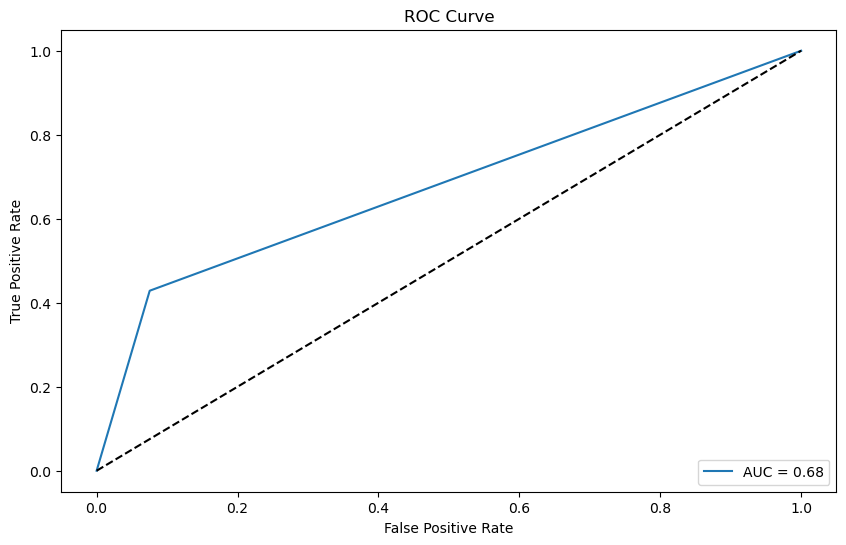

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

# Load and preprocess train and test data
train_data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv"
test_data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_sim_test.csv"

train_data_df = pd.read_csv(train_data_path)
test_data_df = pd.read_csv(test_data_path)

# Extract features (X) and target labels (y) from train and test data
X_train = train_data_df.drop(columns=["Label"])
y_train = train_data_df["Label"]

X_test = test_data_df.drop(columns=["Label"])
y_test = test_data_df["Label"]

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and fit the Isolation Forest model
isolation_forest = IsolationForest(contamination=0.05, random_state=42)
isolation_forest.fit(X_train_scaled)

# Predict outliers on the test data
outliers_test = isolation_forest.predict(X_test_scaled)
outliers_test = np.where(outliers_test == -1, 1, 0)

# Evaluate performance metrics
accuracy = accuracy_score(y_test, outliers_test)
precision = precision_score(y_test, outliers_test)
recall = recall_score(y_test, outliers_test)
f1 = f1_score(y_test, outliers_test)
roc_auc = roc_auc_score(y_test, outliers_test)

confusion = confusion_matrix(y_test, outliers_test)
tn, fp, fn, tp = confusion.ravel()

fpr = fp / (fp + tn)  # False Positive Rate
fnr = fn / (fn + tp)  # False Negative Rate
tnr = tn / (tn + fp)  # True Negative Rate

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC AUC:", roc_auc)
print("False Positive Rate (FPR):", fpr)
print("False Negative Rate (FNR):", fnr)
print("True Negative Rate (TNR):", tnr)
print("Confusion Matrix:\n", confusion)

# Visualize the ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, outliers_test)
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


Accuracy: 0.6881720430107527
Precision: 0.8382352941176471
Recall: 0.42857142857142855
F1-Score: 0.5671641791044777
ROC AUC: 0.6766144814090019
False Positive Rate (FPR): 0.07534246575342465
False Negative Rate (FNR): 0.5714285714285714
True Negative Rate (TNR): 0.9246575342465754
Confusion Matrix:
 [[135  11]
 [ 76  57]]


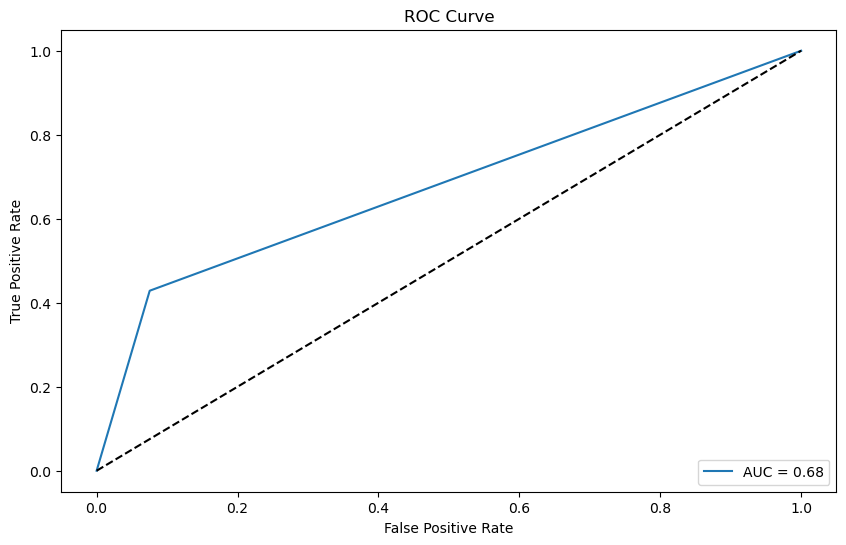

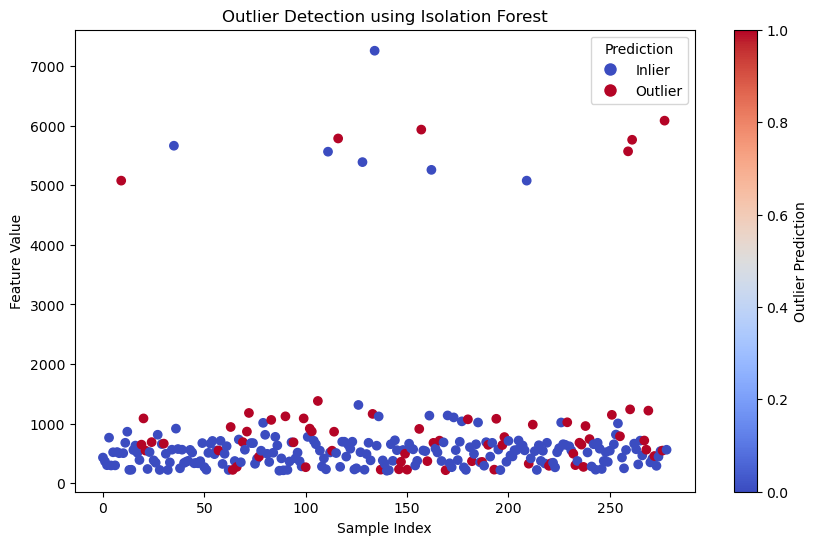

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

# Load and preprocess train and test data
train_data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv"
test_data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_sim_test.csv"

train_data_df = pd.read_csv(train_data_path)
test_data_df = pd.read_csv(test_data_path)

# Extract features (X) and target labels (y) from train and test data
X_train = train_data_df.drop(columns=["Label"])
y_train = train_data_df["Label"]

X_test = test_data_df.drop(columns=["Label"])
y_test = test_data_df["Label"]

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and fit the Isolation Forest model
isolation_forest = IsolationForest(contamination=0.05, random_state=42)
isolation_forest.fit(X_train_scaled)

# Predict outliers on the test data
outliers_test = isolation_forest.predict(X_test_scaled)
outliers_test = np.where(outliers_test == -1, 1, 0)

# Evaluate performance metrics
accuracy = accuracy_score(y_test, outliers_test)
precision = precision_score(y_test, outliers_test)
recall = recall_score(y_test, outliers_test)
f1 = f1_score(y_test, outliers_test)
roc_auc = roc_auc_score(y_test, outliers_test)

confusion = confusion_matrix(y_test, outliers_test)
tn, fp, fn, tp = confusion.ravel()

fpr = fp / (fp + tn)  # False Positive Rate
fnr = fn / (fn + tp)  # False Negative Rate
tnr = tn / (tn + fp)  # True Negative Rate

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC AUC:", roc_auc)
print("False Positive Rate (FPR):", fpr)
print("False Negative Rate (FNR):", fnr)
print("True Negative Rate (TNR):", tnr)
print("Confusion Matrix:\n", confusion)

# Visualize the ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, outliers_test)
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# # Visualize outliers against data points using scatter plot
# plt.figure(figsize=(10, 6))
# plt.scatter(range(len(X_test)), X_test['FeatureColumn'], c=outliers_test, cmap='coolwarm')
# plt.xlabel('Sample Index')
# plt.ylabel('Feature Value')
# plt.title('Outlier Detection using Isolation Forest')
# plt.colorbar(label='Outlier Prediction')
# plt.show()

# Visualize outliers against data points using scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(range(len(X_test)), X_test.iloc[:, 0], c=outliers_test, cmap='coolwarm')
plt.xlabel('Sample Index')
plt.ylabel('Feature Value')
plt.title('Outlier Detection using Isolation Forest')

# Add legend
legend_labels = {0: 'Inlier', 1: 'Outlier'}
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(l)),
                      markersize=10, label=legend_labels[l]) for l in legend_labels]
plt.legend(handles=handles, title='Prediction')

plt.colorbar(scatter, label='Outlier Prediction')
plt.show()



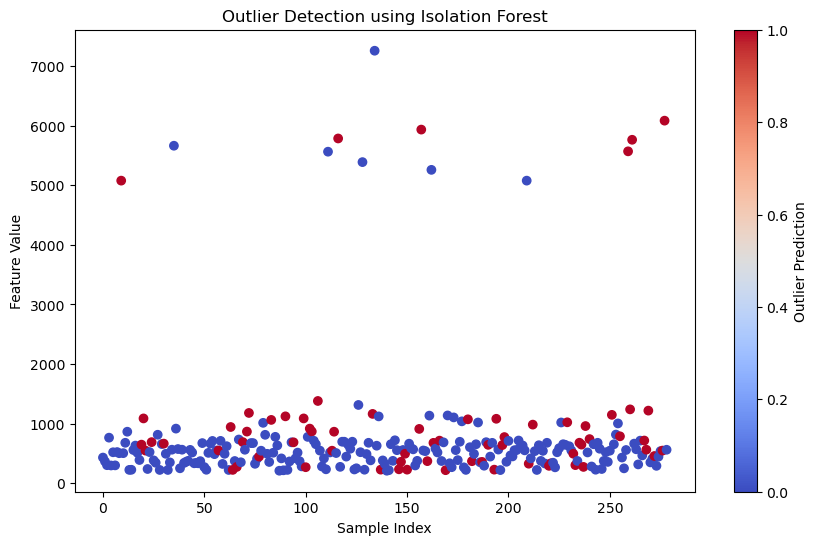

In [7]:
# Visualize outliers against data points using scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(range(len(X_test)), X_test.iloc[:, 0], c=outliers_test, cmap='coolwarm')  # Replace '0' with the column index or name
plt.xlabel('Sample Index')
plt.ylabel('Feature Value')
plt.title('Outlier Detection using Isolation Forest')
plt.colorbar(label='Outlier Prediction')
plt.show()

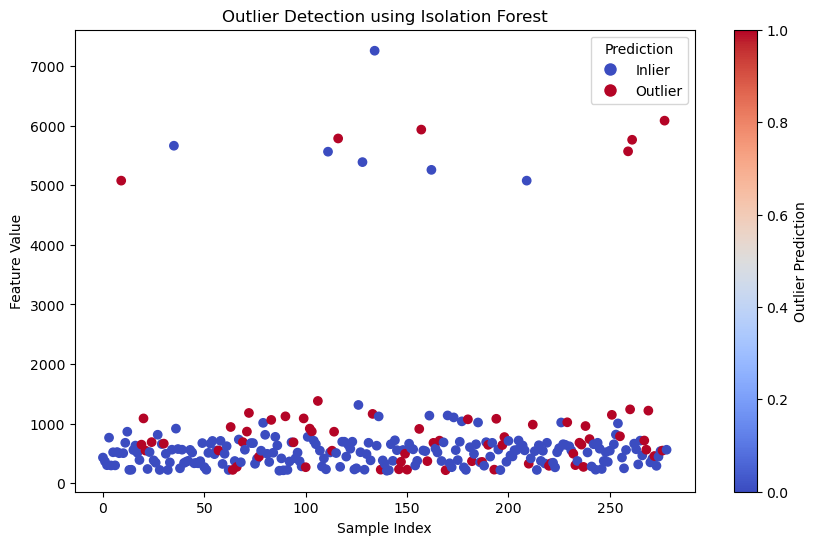

In [8]:
# ...

# Visualize outliers against data points using scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(range(len(X_test)), X_test.iloc[:, 0], c=outliers_test, cmap='coolwarm')
plt.xlabel('Sample Index')
plt.ylabel('Feature Value')
plt.title('Outlier Detection using Isolation Forest')

# Add legend
legend_labels = {0: 'Inlier', 1: 'Outlier'}
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(l)),
                      markersize=10, label=legend_labels[l]) for l in legend_labels]
plt.legend(handles=handles, title='Prediction')

plt.colorbar(scatter, label='Outlier Prediction')
plt.show()


Accuracy: 0.7434931506849315
Precision: 0.9095622119815668
Recall: 0.5407534246575343
F1-Score: 0.6782646048109965
ROC AUC: 0.7434931506849316
False Positive Rate (FPR): 0.053767123287671234
False Negative Rate (FNR): 0.45924657534246577
True Negative Rate (TNR): 0.9462328767123288
Confusion Matrix:
 [[8289  471]
 [4023 4737]]


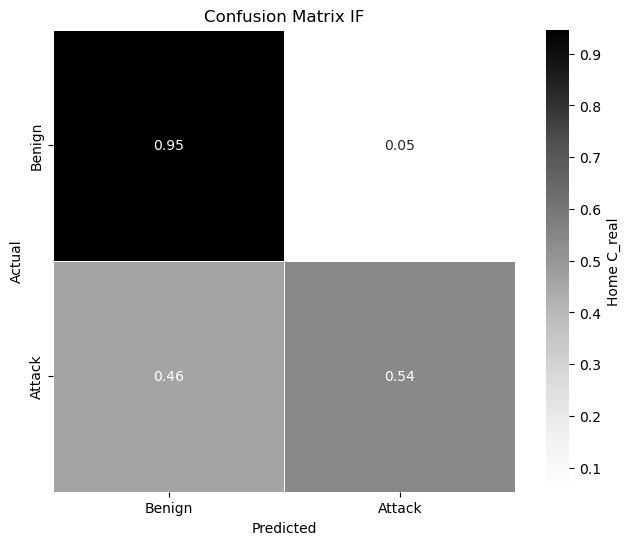

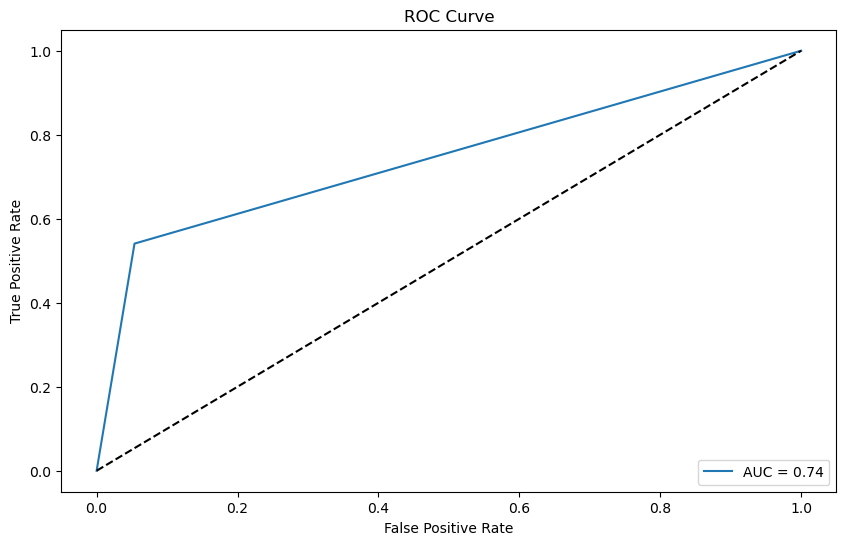

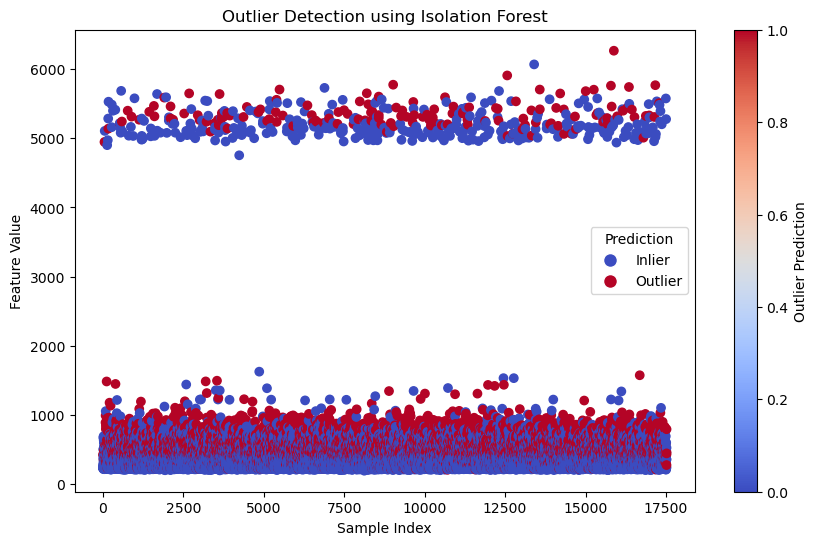

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

# Load and preprocess train and test data
train_data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_unsupervise_train.csv"
test_data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_C_real_test.csv"

train_data_df = pd.read_csv(train_data_path)
test_data_df = pd.read_csv(test_data_path)

# Extract features (X) and target labels (y) from train and test data
X_train = train_data_df.drop(columns=["Label"])
y_train = train_data_df["Label"]

X_test = test_data_df.drop(columns=["Label"])
y_test = test_data_df["Label"]

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and fit the Isolation Forest model
isolation_forest = IsolationForest(contamination=0.05, random_state=42)
isolation_forest.fit(X_train_scaled)

# Predict outliers on the test data
outliers_test = isolation_forest.predict(X_test_scaled)
outliers_test = np.where(outliers_test == -1, 1, 0)

# Evaluate performance metrics
accuracy = accuracy_score(y_test, outliers_test)
precision = precision_score(y_test, outliers_test)
recall = recall_score(y_test, outliers_test)
f1 = f1_score(y_test, outliers_test)
roc_auc = roc_auc_score(y_test, outliers_test)

# confusion = confusion_matrix(y_test, outliers_test)
confusion_matrix = confusion_matrix(y_test, outliers_test)
tn, fp, fn, tp = confusion_matrix.ravel()

fpr = fp / (fp + tn)  # False Positive Rate
fnr = fn / (fn + tp)  # False Negative Rate
tnr = tn / (tn + fp)  # True Negative Rate

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC AUC:", roc_auc)
print("False Positive Rate (FPR):", fpr)
print("False Negative Rate (FNR):", fnr)
print("True Negative Rate (TNR):", tnr)
print("Confusion Matrix:\n", confusion_matrix)

import seaborn as sns

# Calculate the confusion matrix
# conf_matrix = confusion_matrix(y_test, outliers_test)
# tn, fp, fn, tp = conf_matrix.ravel()

# Normalize the confusion matrix
conf_matrix_normalized = confusion_matrix.astype('float') / confusion_matrix.sum(axis=1)[:, np.newaxis]

# Continue with your analysis


# Calculate the confusion matrix
# confusion_matrix = confusion_matrix(y_test, outliers_test)

# Normalize the confusion matrix
# confusion_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create a DataFrame with column and index labels
# cm_df = pd.DataFrame(conf_matrix, columns=['Benign', 'Attack'], index=['Benign', 'Attack'])

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
# sns.heatmap(cm_df, annot=True, fmt='0.2f', cmap='Greys', linewidths=0.5, square=True, cbar_kws={'label': 'Home A'}
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Greys", linewidths=0.5, square=True, 
            cbar_kws={'label': 'Home C_real'},
            xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix IF')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C\IF_C_outliers_real_cm.png',bbox_inches='tight')
# plt.savefig(f'Confusion_Matrix_{name}.png')  # Save with the model name
plt.show()

# Visualize the ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, outliers_test)
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Visualize outliers against data points using scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(range(len(X_test)), X_test.iloc[:, 0], c=outliers_test, cmap='coolwarm')
plt.xlabel('Sample Index')
plt.ylabel('Feature Value')
plt.title('Outlier Detection using Isolation Forest')

# Add legend
legend_labels = {0: 'Inlier', 1: 'Outlier'}
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(l)),
                      markersize=10, label=legend_labels[l]) for l in legend_labels]
plt.legend(handles=handles, title='Prediction')

plt.colorbar(scatter, label='Outlier Prediction')
plt.show()

plt.show()